## Processamento Digital de Imagens - PDI - 2026.1

### Prof. Francisco Zampirolli

### Prof. Celso Kurashima

***

# Lab 6 - Limiarização em Imagens

***

# Limiarização (*Thresholding*)

- É uma das mais importantes abordagens para segmentação de imagens.
- Suponha que o histograma de níveis de cinza corresponda a uma imagem $f(x,y)$ composta por objetos iluminados sobre um fundo escuro, de maneira que os pixels do objeto e os do fundo tenham seus níveis de cinza agrupados em dois grupos denominantes.


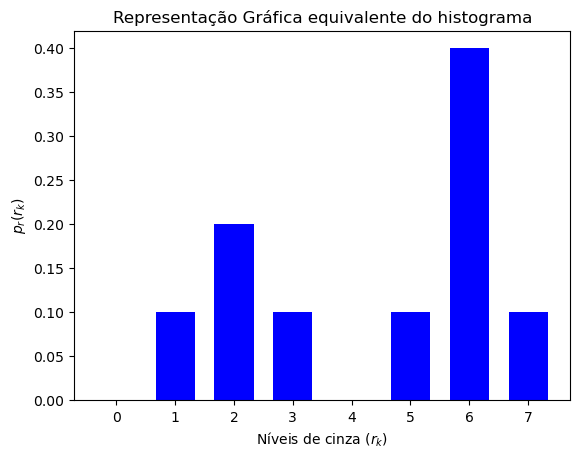

In [1]:
import matplotlib.pyplot as plt
pr = [0.0, 0.1, 0.2, 0.1, 0.0, 0.1, 0.4, 0.1]
n = len(pr)
x = range(n)
width = 1/1.5
plt.bar(x, pr, width, color="blue")
plt.ylabel('$p_r(r_k)$', fontsize=10)
plt.xlabel('Níveis de cinza ($r_k$)', fontsize=10)
plt.title('Representação Gráfica equivalente do histograma')
plt.show()

## Limiarização (*Thresholding*) - equação

- Uma maneira de extrair os objetos do fundo é através da **seleção de um limiar $T$ que separe os dois grupos**;
- **Hipótese:** a escala de níveis de cinza do objeto de interesse é diferente da escala de níveis de cinza do fundo da imagem.

$$ g(x,y) = \left \{ \begin{array}{cc}
1 & se \ f(x,y) > T \\
0 & se \ f(x,y) \leq T
\end{array}
 \right .
$$

- Qual seria o limiar $T$ no histograma anterior/seguinte?

### Exemplo 1

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
from morph import *

In [6]:
mm.install()

In [7]:
img1 = mm.read('https://drive.google.com/file/d/1RuumLbQeD-y16H0ZovMUtae-vcjmk1V0/view?usp=sharing')

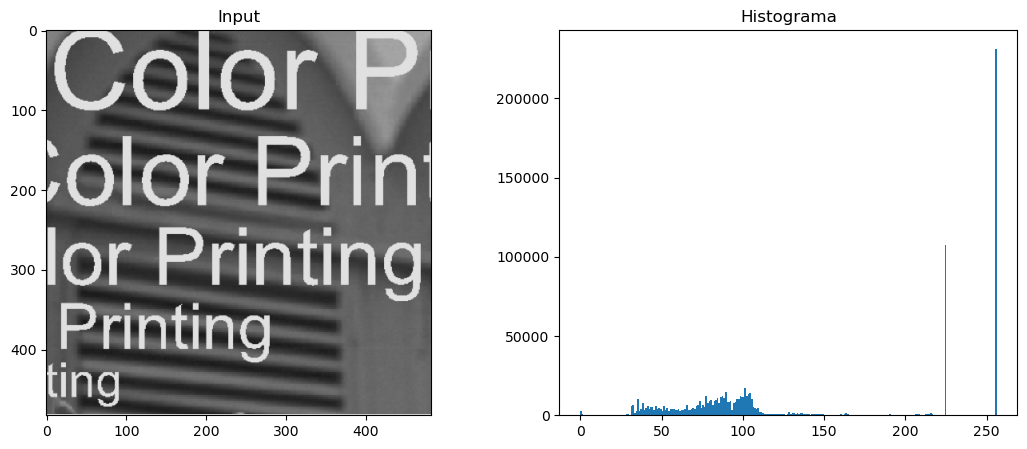

In [8]:
plt.figure(figsize=(13,5))
plt.subplot(121),plt.imshow(img1,"gray"),plt.title('Input')
plt.subplot(122),plt.hist(img1.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
plt.show()

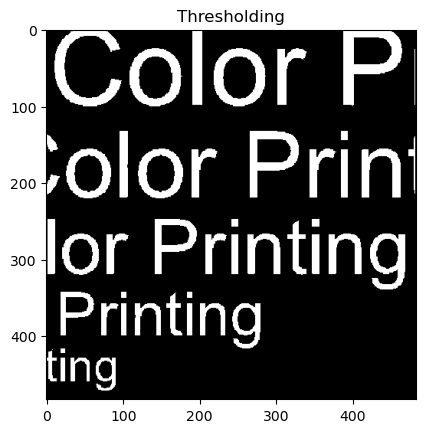

In [9]:
# Aplicando LIMIAR
#
# Converte imagem RGBA para escala de cinza
img_gray = cv2.cvtColor(img1, cv2.COLOR_RGBA2GRAY)

# Ou, se a imagem for BGR/RGB, use:
# img_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# Aplica o thresholding
plt.imshow(img_gray > 175, cmap='gray')
plt.title('Thresholding')
plt.show()   

### Exemplo 2

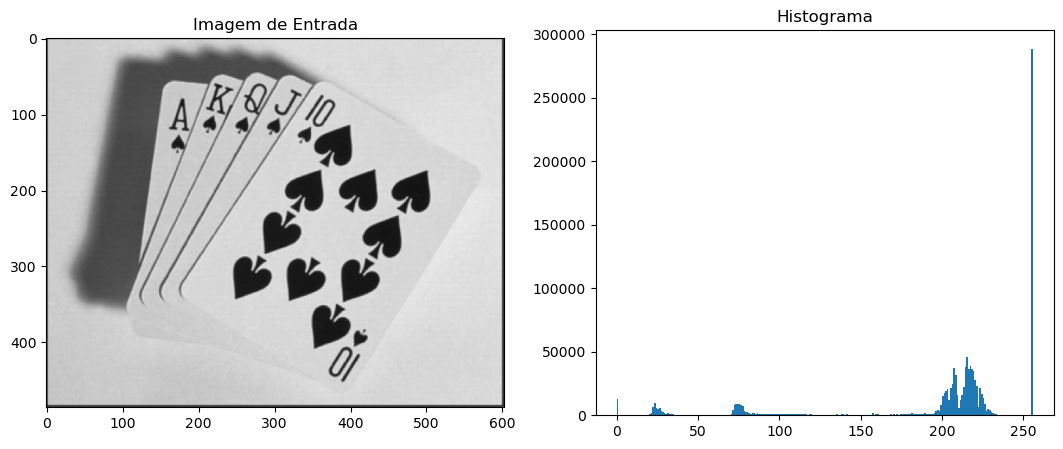

In [10]:
img2 = mm.read('https://drive.google.com/file/d/1bD6qx5bab9-V8zfP1D4AluqtONyY7i6U/view?usp=sharing')

plt.figure(figsize=(13,5))
plt.subplot(121),plt.imshow(img2,"gray"),plt.title('Imagem de Entrada')
plt.subplot(122),plt.hist(img2.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
plt.show()

- Se usar um valor errado para o limiar T, o resultado poderá ser insatisfatório.

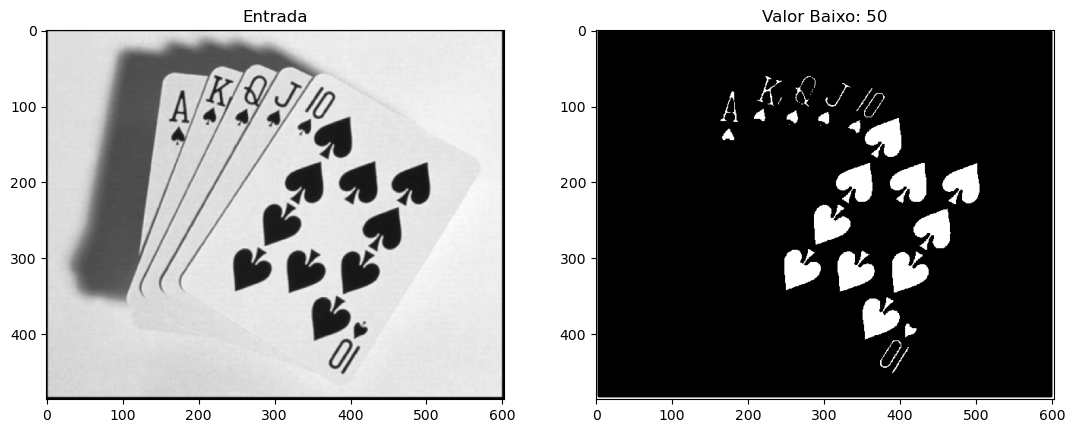

In [27]:
# Aplicando LIMIAR
#
limiar = 50

img2gray = cv2.cvtColor(img2, cv2.COLOR_RGBA2GRAY)

plt.figure(figsize=(13,5))
plt.subplot(121),plt.imshow(img2gray,"gray"),plt.title('Entrada')
plt.subplot(122),plt.imshow(img2gray<limiar,"gray"),plt.title('Valor Baixo: '+str(limiar))

plt.show()

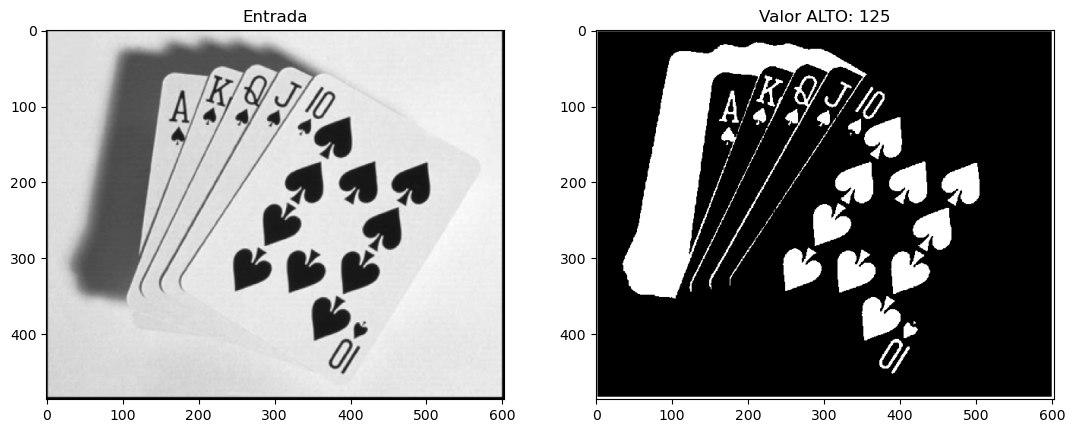

In [12]:
# ALTERANDO O LIMIAR
#
limiar = 125

plt.figure(figsize=(13,5))
plt.subplot(121),plt.imshow(img2gray,"gray"),plt.title('Entrada')
plt.subplot(122),plt.imshow(img2gray<limiar,"gray"),plt.title('Valor ALTO: '+str(limiar))
plt.show()

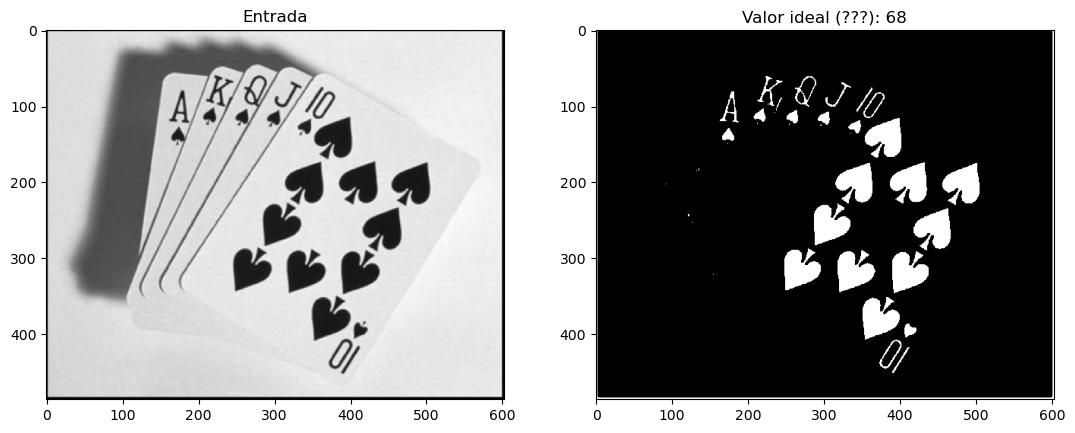

In [13]:
# Alterando NOVAMENTE O LIMIAR
#
limiar = 68

plt.figure(figsize=(13,5))
plt.subplot(121),plt.imshow(img2gray,"gray"),plt.title('Entrada')
plt.subplot(122),plt.imshow(img2gray<limiar,"gray"),plt.title('Valor ideal (???): '+str(limiar))
plt.show()

## Limiarização (*Thresholding*)

Modos de se escolher um Limiar:

1. Inspeção visual do histograma
2. Tentativa e erro
3. Threshold Automático

## Limiarização (*Thresholding*)

1. Inspeção visual do histograma
    - Imagem \\(f(x, y)\\) composta de objetos brilhantes sobre fundo escuro (ou vice-versa);
    - Um ponto $(x, y)$ é parte do objeto se $f(x, y) > T$;
    - Se $T_1 < f(x, y) \leq T_2$ - o ponto $(x, y)$ pertence a uma classe de objetos;
    - Se $f(x, y) > T_2$ - o ponto $(x, y)$ pertence a outra classe;
    - Se $f(x, y) \leq T_1$ - o ponto $(x, y)$ pertence ao fundo.

    > **Dificuldade:** estabelecer múltiplos T que efetivamente isolem regiões de interesse.

2. Tentativa e erro
3. Threshold Automático


### Exemplo 3

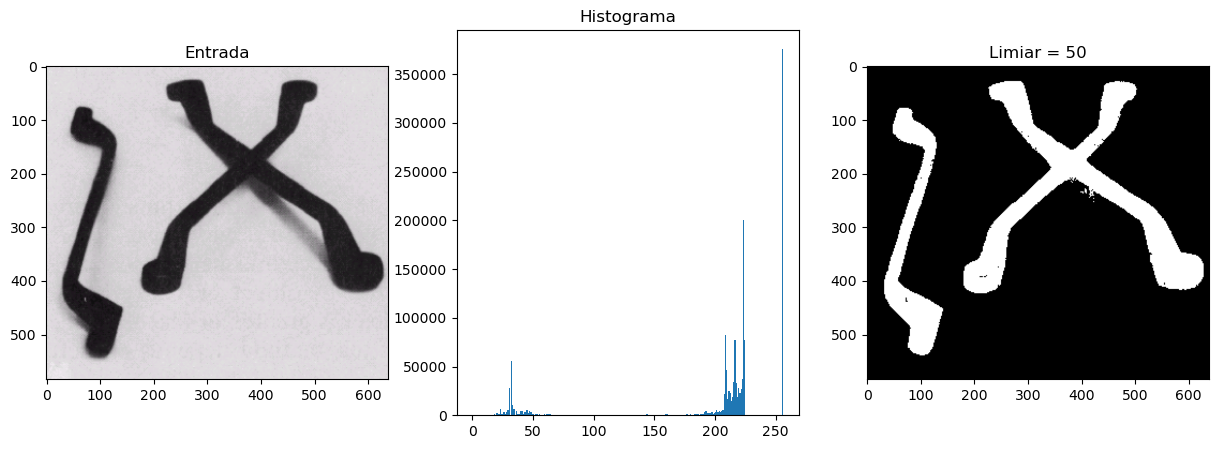

In [14]:
# Aplicando LIMIAR por Inspeção visual do histograma
#
limiar = 50

img3 = mm.read('https://drive.google.com/file/d/11jQYsp2Zm93TJZlnUZWyl83EVl9NLb3H/view?usp=sharing')
img3gray = cv2.cvtColor(img3, cv2.COLOR_RGBA2GRAY)

plt.figure(figsize=(15,5))
plt.subplot(131),plt.imshow(img3,"gray"),plt.title('Entrada')
plt.subplot(132),plt.hist(img3.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
plt.subplot(133),plt.imshow(img3gray<limiar,"gray"),plt.title('Limiar = 50')
plt.show()

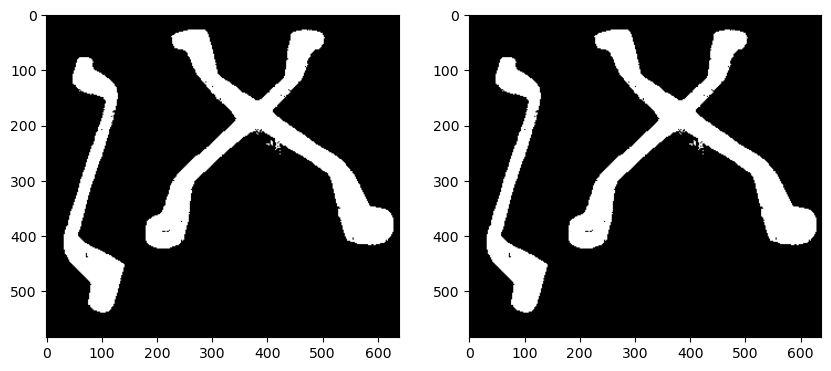

In [15]:
# Código (Numérico vs Lógico) 
f = img3gray

limiar = 50

g = np.zeros((f.shape))
L, C = g.shape
for i in range(0,L): # para cada linha i
    for j in range(0,C): # para cada coluna j
        if f[i,j] < limiar:
            g[i,j] = 1

plt.figure(figsize=(10,10))
plt.subplot(121),plt.imshow(g,"gray") # ou
plt.subplot(122),plt.imshow(f<limiar,"gray")
plt.show()

### Exemplo 4

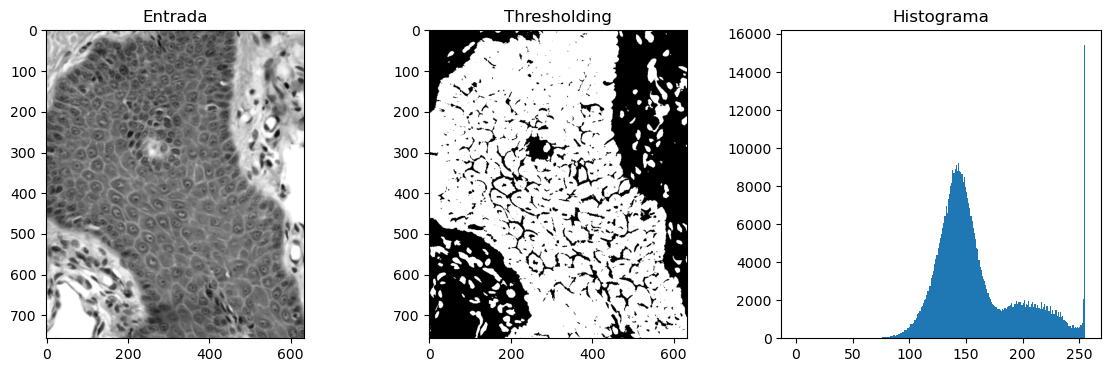

In [16]:
# Exemplo Epitelial
#
limiar = 160

img4 = mm.read('https://drive.google.com/file/d/1bBZnrQdlybhXEF57FeXH9JM-tBdbipA9/view?usp=sharing')
img4gray = cv2.cvtColor(img4, cv2.COLOR_RGBA2GRAY)

plt.figure(figsize=(14,4))
plt.subplot(131),plt.imshow(img4gray, cmap='gray'),plt.title('Entrada')
plt.subplot(132),plt.imshow(img4gray<limiar,"gray"),plt.title('Thresholding')
plt.subplot(133),plt.hist(img4gray.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
plt.show()

## Limiarização (*Thresholding*)

1. Inspeção visual do histograma

  > **Dificuldade:** estabelecer múltiplos T que efetivamente isolem regiões de interesse.

2. Tentativa e erro
    - Aplicado em processos iterativos.
    - O usuário testa diferentes níveis de Limiar até produzir um resultado satisfatório de acordo com o observador.

3. Threshold Automático


## Limiarização (*Thresholding*)

### *Thresholding* Automático - **Algoritmo simples:**
    
1. Selecionar um valor estimado para $T$ (exemplo: ponto intermediário entre os valores mínimos e máximos de intensidade da imagem)
2. Limiarizar a imagem usando $T$. Isso produzirá dois grupos de pixels:
   - $G_1$ consiste de todos os pixels com valores de níveis de cinza $> T$
   - $G_2$ consiste de todos os pixels com níveis de cinza $\leq T$

3. Calcular a média dos níveis de cinza $\mu_1$ e $\mu_2$ para cada região de pixels $G_1$ e $G_2$

4. Calcular o novo valor do limiar:
    $$ T = 0.5*(\mu_1+\mu_2)$$
5. Repetir os passo 2 a 4 até que a diferença em $T$ em sucessivas iterações seja menor que um $T_o$ pré-estabelecido.

### Exemplo 5

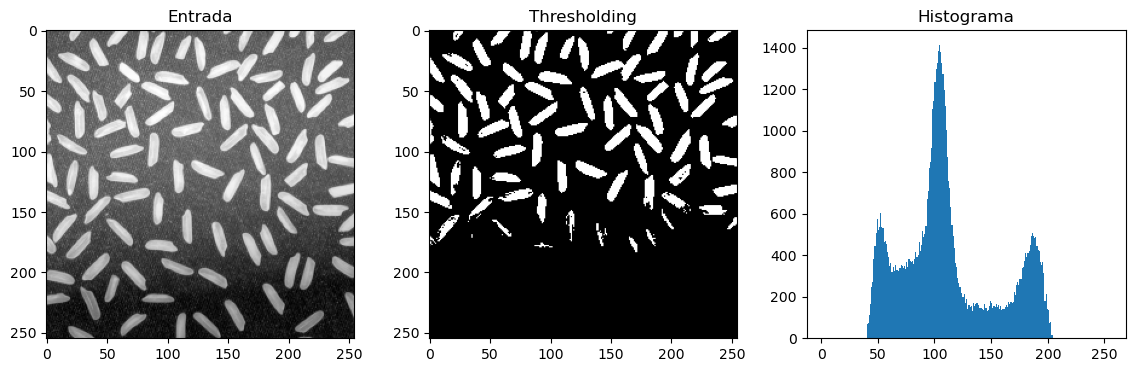

In [17]:
# Exemplo Grãos 
#
#(antes de executar certifique que tem o "rice.png" na sua pasta)
#
limiar = 170

img5gray = cv2.imread("rice.png",0)
f = img5gray
f = f[30:285,85:340]

plt.figure(figsize=(14,4))
plt.subplot(131),plt.imshow(f,"gray"),plt.title('Entrada')
plt.subplot(132),plt.imshow(f > limiar,"gray"),plt.title('Thresholding')
plt.subplot(133),plt.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')
plt.show()

# RESPONDA: Por que aqui usamos "f > limiar" (sinal de maior) ???

In [18]:
# Agora ESTUDE este algoritmo de "procura" de um LIMIAR
#
# (atenção para a variável "precisao"): COMPARE "T1" e "T"
#
f = cv2.imread('rice.png',0)
f = f[30:285,85:340]
precisao = 0.0001

valorMin, valorMax = int(np.amin(f)), int(np.amax(f))
print(f'min={valorMin}, max={valorMax}')
T1 = (valorMin+valorMax)/2;
print(T1)
done = False;
while not done:
    g = (f >= T1) # limiarizações
    T1next = 0.5*(np.mean(f[g]) + np.mean(f[~g]))
    done = np.abs(T1 - T1next) < precisao
    print(f'\n{precisao} {np.abs(T1 - T1next)}')
    T1 = T1next
    print('T1 = ',T1)
    pass

# s1 é o resultado do threshold Binário do OpenCV, aplicando LIMIAR = T1
#
T,s1 = cv2.threshold(f,T1,255,cv2.THRESH_BINARY)
print('T: cv2.threshold = ',T)

min=40, max=204
122.0

0.0001 6.438731513044615
T1 =  128.43873151304462

0.0001 2.3581737343015448
T1 =  130.79690524734616

0.0001 0.5044506461794072
T1 =  131.30135589352557

0.0001 0.25579098911953224
T1 =  131.5571468826451

0.0001 0.0
T1 =  131.5571468826451
T: cv2.threshold =  131.0


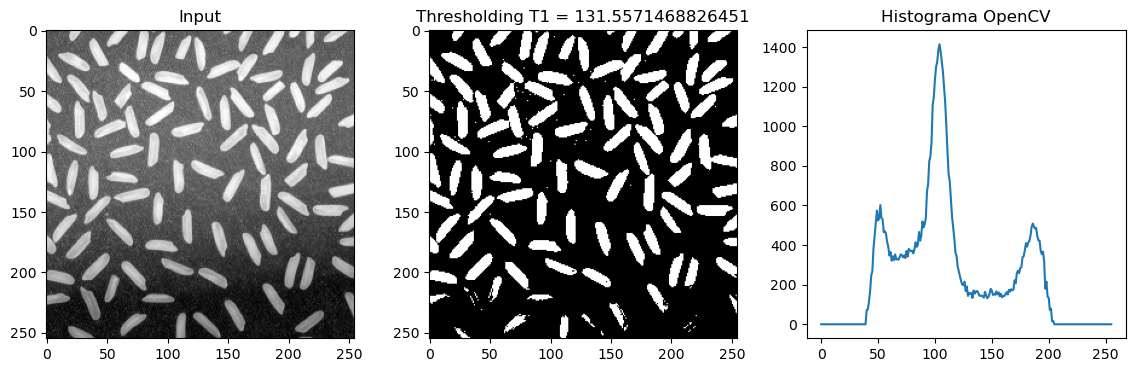

In [19]:
# Plotar o resultado
#
hf = cv2.calcHist([f],[0],None,[256],[0,256])
plt.figure(figsize=(14,4))
plt.subplot(131),plt.imshow(f,"gray"),plt.title('Input')
plt.subplot(132),plt.imshow(s1,"gray"),plt.title('Thresholding T1 = '+str(T1))
plt.subplot(133),plt.plot(hf),plt.title('Histograma OpenCV')

plt.show()

## Limiarização de Otsu
    
- Tratar o Histograma da Imagem como uma Função Densidade de Probabilidade Discreta:
$$ P_r(r_q) = \frac{n_q}{n}$$

onde:
   - $L$ é o número total dos possíveis níveis de intensidade da imagem
   - $q=0,1,\cdots,L-1$ são os níveis de cinza
   - $n$ é o número total de pixels da imagem
   - $n_q$ é o número de pixels com intensidade $r_q$

## Limiarização de Otsu

- Um valor $k$ para o Threshold pode ser escolhido tal que:
    - $C_0$ seja a classe de pixels com níveis entre $[0, k-1]$ e
    - $C_1$ seja a classe de píxels com níveis entre $[k, L-1]$

- O método de Otsu escolhe $k$ tal que maximize a variância inter-classes:

$$ \sigma^2_B = w_0(\mu_0-\mu_T)^2 + w_1(\mu_1-\mu_T)^2$$

onde:
   - $w_0 = \sum_{q=0}^{k-1} p_q(r_q)$
   - $w_1 = \sum_{q=k}^{L-1} p_q(r_q)$
   - $\mu_0 = \sum_{q=0}^{k-1} qp_q(r_q)/w_0$
   - $\mu_1 = \sum_{q=k}^{L-1} qp_q(r_q)/w_1$
   - $\mu_T = \sum_{q=0}^{L-1} qp_q(r_q)$

131.0


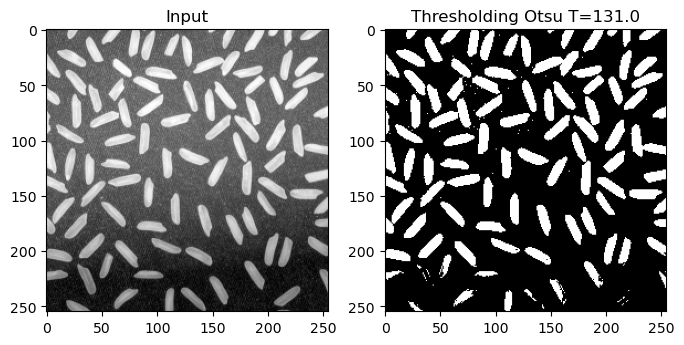

In [20]:
# Usando limiarização de OTSU: cv2.THRESH_OTSU
#
f = cv2.imread('rice.png',0)
f = f[30:285,85:340]
T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU) #<<<<<<<<<<
print(T)
plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(f,"gray"),plt.title('Input')
plt.subplot(122),plt.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))
plt.show()

### Explorando a bibioteca morph.py

In [21]:
from morph import *

In [22]:
help(mm.threshold)

Help on function threshold in module morph:

threshold(img, limiar=0)
    Thresholds an input image by a threshold value or using Otsu's method.
    input: <numpy.ndarray> Input image to be thresholded.
    output: <numpy.ndarray> Thresholded image.
    Examples:
    img = mm.read('image.png')
    th = mm.threshold(img)



In [23]:
help(mm.show)

Help on function show in module morph:

show(*args)
    This function will draw images f
    input: <*args> set of images f_i, where i>0 is binary image
    output: image drawing
    Example:
    f1, f2 = np.zeros((100, 100,3)),  np.zeros((100, 100))
    f2[50:60, 50:60] = 1
    mm.show(f1, f2)



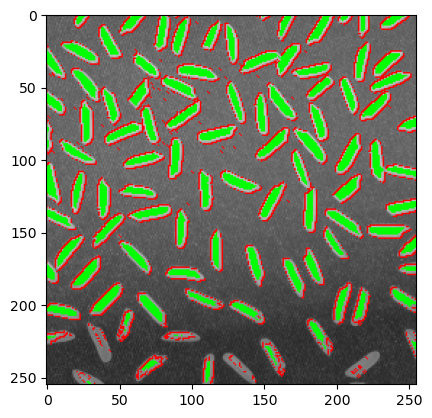

In [24]:
# Aplicando Erosão e Dilatação
#
img9 = mm.threshold(f)

mm.show(cv2.imread('rice.png')[30:285,85:340,:],
        mm.dil(img9)-img9,
        mm.ero(img9,mm.secross(1)))

# 
# RESPONDA: o que significa este resultado ???

- - - - -